In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import brentq

# ==========================================================
# Two ideal RC arcs in series:
# Z = R1/(1+j*w*R1*C1) + R2/(1+j*w*R2*C2)
# (Rs can be added if needed)
#
# Finds Nyquist inflection point using second derivative
# of the parametric curve Z''(Z')
# ==========================================================



In [20]:
    # -----------------------------
    # impedance model
    # -----------------------------
    def Z_RC(R, C, w):
        return R / (1 + 1j*w*R*C)
    
    def total_impedance(w):
        return Rs + Z_RC(R1, C1, w) + Z_RC(R2, C2, w)


In [151]:
fs = []
Zs = []
R1s = 0.01*np.array([1])
for R1 in R1s:
    # -----------------------------
    # USER PARAMETERS
    # -----------------------------
    # R1 = 0.01*i     # ohm
    C1 = 0.05       # F
    
    R2 = 0.01      # ohm
    C2 = 0.1       # F
    
    Rs = 0.0        # series resistance
    
    fmin = 0.1
    fmax = 2e4
    npts = 4000
    
    

    
    
    # -----------------------------
    # frequency grid
    # -----------------------------
    f = np.logspace(np.log10(fmin), np.log10(fmax), npts)
    w = 2 * np.pi * f
    t = np.log10(f)
    
    Z = total_impedance(w)
    
    x = np.real(Z)      # Z'
    y = -np.imag(Z)     # Nyquist uses -Z''
    
    # ==========================================================
    # CURVATURE OF PARAMETRIC CURVE x(t), y(t)
    #
    # kappa = (x' y'' - y' x'') / (x'^2 + y'^2)^(3/2)
    # ==========================================================
    
    dx = np.gradient(x, t)
    dy = np.gradient(y, t)
    
    d2x = np.gradient(dx, t)
    d2y = np.gradient(dy, t)
    
    num = dx * d2y - dy * d2x
    den = (dx**2 + dy**2)**1.5
    
    kappa = num / den
    
    # smooth numerical noise
    kappa = savgol_filter(kappa, 51, 3)
    
    
    # ==========================================================
    # Find arc maxima in Nyquist plot
    # (used to define "between arcs")
    # ==========================================================
    
    # local maxima of y
    peaks = []
    for i in range(1, len(y)-1):
        if y[i] > y[i-1] and y[i] > y[i+1]:
            peaks.append(i)
    
    if len(peaks) < 2:
        raise RuntimeError("Less than two distinguishable arcs found.")
    
    # two strongest peaks
    peaks = sorted(peaks, key=lambda i: y[i], reverse=True)[:2]
    peaks = sorted(peaks)
    
    i1, i2 = peaks[0], peaks[1]
    
    # region between arcs
    lo = min(i1, i2)
    hi = max(i1, i2)
    
    # ==========================================================
    # Most negative curvature between arcs
    # ==========================================================
    region = slice(lo, hi + 1)
    idx_local = np.argmin(kappa[region])
    idx = lo + idx_local
    
    f_neck = f[idx]
    Z_neck = Z[idx]

    fs.append(f_neck)
    Zs.append(Z_neck)
    
    print("Most negative curvature point between arcs:")
    print(f"f     = {f_neck:.6g} Hz")
    print(f"Z'    = {np.real(Z_neck):.6g} ohm")
    print(f"-Z''  = {-np.imag(Z_neck):.6g} ohm")
    print(f"kappa = {kappa[idx]:.6g}")
    
    
    # # ==========================================================
    # # PLOTS
    # # ==========================================================
    # fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # # Nyquist
    plt.plot(x, y, lw=2)
    plt.plot(x[i1], y[i1], 'go', label='Arc peak 1')
    plt.plot(x[i2], y[i2], 'bo', label='Arc peak 2')
    plt.plot(x[idx], y[idx], 'ro', ms=8, label='Most negative curvature')
    plt.xlabel("Z' (ohm)")
    plt.ylabel("-Z'' (ohm)")
    plt.title("Nyquist Plot")
    plt.grid(True)
    plt.axis('equal')
    # plt.legend()
    
    # # curvature vs frequency
    # ax[1].semilogx(f, kappa, lw=2)
    # ax[1].axvline(f[idx], color='r', ls='--', label='Selected point')
    # ax[1].set_xlabel("Frequency (Hz)")
    # ax[1].set_ylabel("Curvature")
    # ax[1].set_title("Curvature vs Frequency")
    # ax[1].grid(True)
    # ax[1].legend()
    
    # plt.tight_layout()
    # plt.show()

RuntimeError: Less than two distinguishable arcs found.

In [ ]:
plt.plot(x,dy/dx)
plt.ylim(1,-1)
plt.axhline(0)

0.6102456575176741
0.6324555320336759


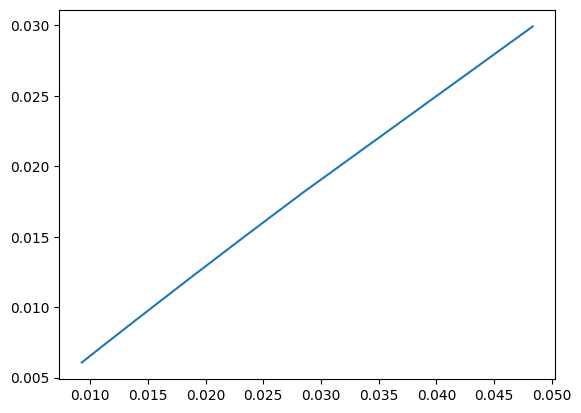

In [138]:
Zs = np.array(Zs)
plt.plot(Zs.real,-Zs.imag,'-')
k,q = np.polyfit(Zs.real,-Zs.imag,1)
print(k)
print(2*np.sqrt(C1/C2))

6.481052882988266


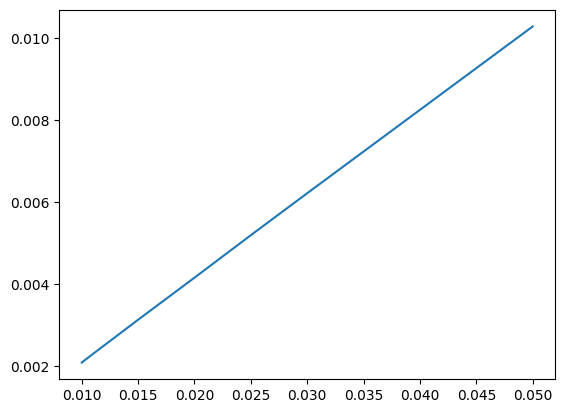

In [141]:
plt.plot(R1s,1/np.array(fs))
k,q = np.polyfit(R1s,1/np.array(fs),1)
print(k/np.sqrt(C1*C2))
# plt.xlim(0,6)
# plt.ylim(0,0.02)

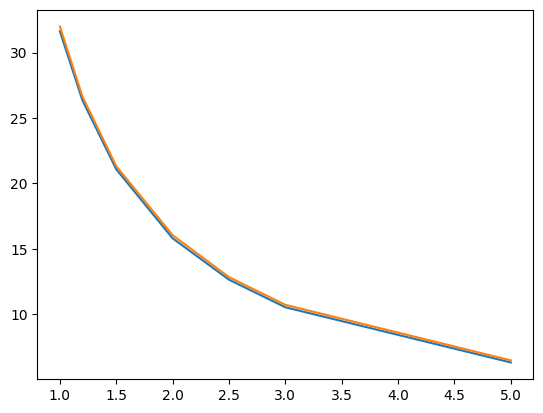

In [140]:
plt.plot(np.array([1,1.2,1.5,2,2.5,3,5]),1/(np.sqrt(C1*C2)*np.array([1,1.2,1.5,2,2.5,3,5])))
plt.plot(np.array([1,1.2,1.5,2,2.5,3,5]),np.array(fs)/15)

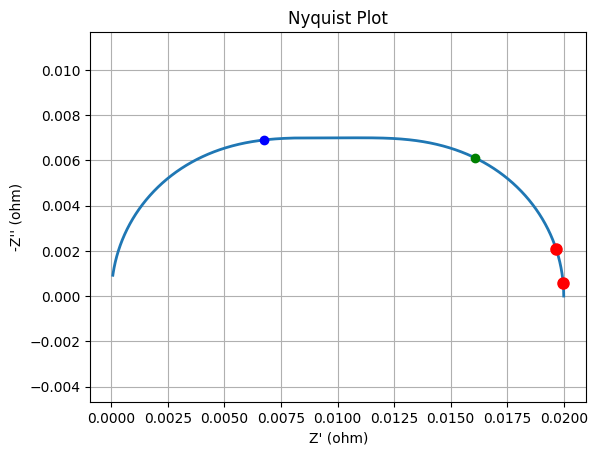

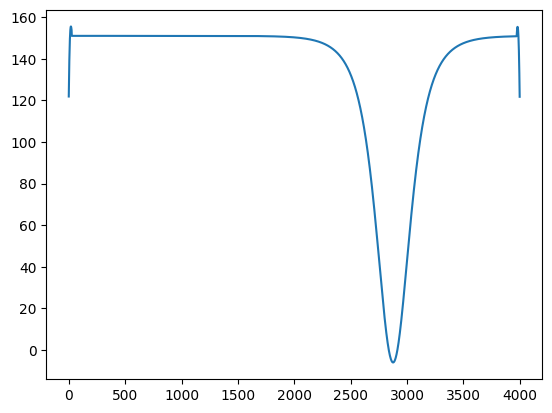

In [158]:
fs = []
Zs = []
R1s = 0.01*np.array([1])
for R1 in R1s:
    # -----------------------------
    # USER PARAMETERS
    # -----------------------------
    # R1 = 0.01*i     # ohm
    C1 = 0.01       # F
    
    R2 = 0.01      # ohm
    C2 = 0.06       # F
    
    Rs = 0.0        # series resistance
    
    fmin = 0.1
    fmax = 2e4
    npts = 4000
    
    

    
    
    # -----------------------------
    # frequency grid
    # -----------------------------
    f = np.logspace(np.log10(fmin), np.log10(fmax), npts)
    w = 2 * np.pi * f
    t = np.log10(f)
    
    Z = total_impedance(w)
    
    x = np.real(Z)      # Z'
    y = -np.imag(Z)     # Nyquist uses -Z''
    
    # ==========================================================
    # CURVATURE OF PARAMETRIC CURVE x(t), y(t)
    #
    # kappa = (x' y'' - y' x'') / (x'^2 + y'^2)^(3/2)
    # ==========================================================
    
    dx = np.gradient(x, t)
    dy = np.gradient(y, t)
    
    d2x = np.gradient(dx, t)
    d2y = np.gradient(dy, t)
    
    num = dx * d2y - dy * d2x
    den = (dx**2 + dy**2)**1.5
    
    kappa = num / den
    
    # smooth numerical noise
    kappa = savgol_filter(kappa, 51, 3)
    
    
    # # ==========================================================
    # # Find arc maxima in Nyquist plot
    # # (used to define "between arcs")
    # # ==========================================================
    
    # # local maxima of y
    # peaks = []
    # for i in range(1, len(y)-1):
    #     if y[i] > y[i-1] and y[i] > y[i+1]:
    #         peaks.append(i)
    
    # if len(peaks) < 2:
    #     raise RuntimeError("Less than two distinguishable arcs found.")
    
    # # two strongest peaks
    # peaks = sorted(peaks, key=lambda i: y[i], reverse=True)[:2]
    # peaks = sorted(peaks)
    
    # i1, i2 = peaks[0], peaks[1]
    
    # # region between arcs
    # lo = min(i1, i2)
    # hi = max(i1, i2)
    
    # # ==========================================================
    # # Most negative curvature between arcs
    # # ==========================================================
    # region = slice(lo, hi + 1)
    # idx_local = np.argmin(kappa[region])
    # idx = lo + idx_local
    
    # f_neck = f[idx]
    # Z_neck = Z[idx]

    # fs.append(f_neck)
    # Zs.append(Z_neck)
    
    # print("Most negative curvature point between arcs:")
    # print(f"f     = {f_neck:.6g} Hz")
    # print(f"Z'    = {np.real(Z_neck):.6g} ohm")
    # print(f"-Z''  = {-np.imag(Z_neck):.6g} ohm")
    # print(f"kappa = {kappa[idx]:.6g}")
    
    
    # # # ==========================================================
    # # PLOTS
    # # ==========================================================
    # fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # # Nyquist
    plt.plot(x, y, lw=2)
    plt.plot(x[i1], y[i1], 'go', label='Arc peak 1')
    plt.plot(x[i2], y[i2], 'bo', label='Arc peak 2')
    plt.plot(x[idx], y[idx], 'ro', ms=8, label='Most negative curvature')
    plt.xlabel("Z' (ohm)")
    plt.ylabel("-Z'' (ohm)")
    plt.title("Nyquist Plot")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

    plt.plot(kappa)
    plt.show()
    # plt.legend()
    
    # # curvature vs frequency
    # ax[1].semilogx(f, kappa, lw=2)
    # ax[1].axvline(f[idx], color='r', ls='--', label='Selected point')
    # ax[1].set_xlabel("Frequency (Hz)")
    # ax[1].set_ylabel("Curvature")
    # ax[1].set_title("Curvature vs Frequency")
    # ax[1].grid(True)
    # ax[1].legend()
    
    # plt.tight_layout()
    # plt.show()

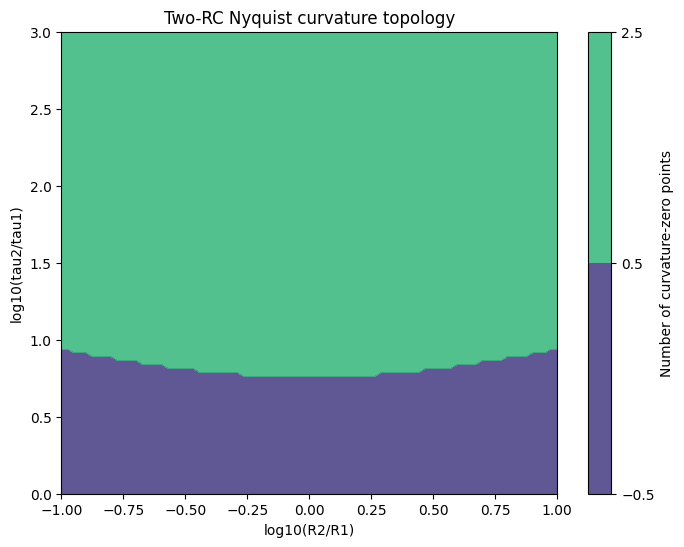

In [156]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Two ideal RC processes in series
# Scan parameter space for number of curvature zero points
# ==========================================================

R1 = 1.0
tau1 = 1.0

# parameter grid
r_vals = np.logspace(-1, 1, 80)      # R2/R1
lam_vals = np.logspace(0, 3, 120)    # tau2/tau1

# frequency grid
w = np.logspace(-4, 4, 5000)
t = np.log10(w)

result = np.zeros((len(lam_vals), len(r_vals)))

# ----------------------------------------------------------
def impedance(R, tau, w):
    return R / (1 + 1j*w*tau)

# ----------------------------------------------------------
for i, lam in enumerate(lam_vals):
    tau2 = lam * tau1

    for j, r in enumerate(r_vals):
        R2 = r * R1

        Z = impedance(R1, tau1, w) + impedance(R2, tau2, w)

        x = np.real(Z)
        y = -np.imag(Z)

        # derivatives wrt log(w)
        dx = np.gradient(x, t)
        dy = np.gradient(y, t)

        d2x = np.gradient(dx, t)
        d2y = np.gradient(dy, t)

        K = dx*d2y - dy*d2x

        # sign changes = zero-curvature points
        s = np.sign(K)
        idx = np.where(np.diff(s) != 0)[0]

        nzeros = len(idx)

        # classify
        if nzeros >= 2:
            result[i, j] = 2
        else:
            result[i, j] = 0

# ==========================================================
# Plot phase map
# ==========================================================
plt.figure(figsize=(8,6))

plt.contourf(
    np.log10(r_vals),
    np.log10(lam_vals),
    result,
    levels=[-0.5,0.5,2.5],
    alpha=0.85
)

plt.colorbar(label="Number of curvature-zero points")

plt.xlabel("log10(R2/R1)")
plt.ylabel("log10(tau2/tau1)")
plt.title("Two-RC Nyquist curvature topology")

plt.show()